<a href="https://colab.research.google.com/github/aleesha33/Medical-Document-Classification-using-NLP-and-ML/blob/main/medical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/medical_documents_dataset.csv")
df.head()

,ocr_lines,text,file_format,label
0,"['Apollo Hospital', 'Prescription', 'Patient N...",Apollo Hospital Prescription Patient Name: Roh...,png,prescription
1,"['Fortis Healthcare', 'Prescription', 'Patient...",Fortis Healthcare Prescription Patient Name: A...,jpg,prescription
2,"['Max Healthcare', 'Prescription', 'Patient Na...",Max Healthcare Prescription Patient Name: Neha...,pdf,prescription
3,"['Manipal Hospital', 'Prescription', 'Patient ...",Manipal Hospital Prescription Patient Name: Ne...,png,prescription
4,"['Fortis Healthcare', 'Prescription', 'Patient...",Fortis Healthcare Prescription Patient Name: S...,png,prescription


In [ ]:
df.shape

(16500, 4)

In [ ]:
df.info()

df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16500 entries, 0 to 16499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ocr_lines    16500 non-null  object
 1   text         16500 non-null  object
 2   file_format  16500 non-null  object
 3   label        16500 non-null  object
dtypes: object(4)
memory usage: 515.8+ KB


,0
ocr_lines,0
text,0
file_format,0
label,0


In [ ]:
df['label'].value_counts()

,count
label,
prescription,1500
lab_report,1500
scan_report,1500
discharge_summary,1500
medical_bill,1500
insurance_claim,1500
insurance_policy,1500
medical_history,1500
referral_letter,1500


In [ ]:
#seperating target and features
X = df.iloc[:,:-1]
X
y = df['label']
y

,label
0,prescription
1,prescription
2,prescription
3,prescription
4,prescription
...,...
16495,other
16496,other
16497,other
16498,other


Counter({'prescription': 1500, 'lab_report': 1500, 'scan_report': 1500, 'discharge_summary': 1500, 'medical_bill': 1500, 'insurance_claim': 1500, 'insurance_policy': 1500, 'medical_history': 1500, 'referral_letter': 1500, 'id_proof': 1500, 'other': 1500})


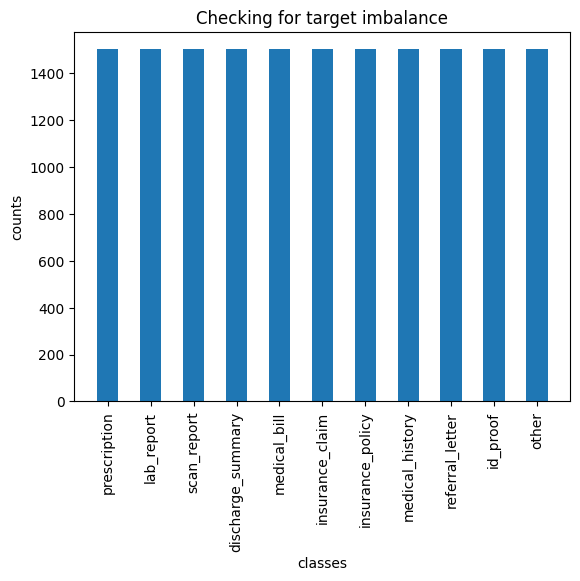

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

counts = Counter(y)

print(counts)

plt.bar(counts.keys(), counts.values(), width=0.5, align='center')
plt.xticks(rotation=90)
plt.xlabel('classes')
plt.ylabel('counts')
plt.title('Checking for target imbalance')
plt.show()

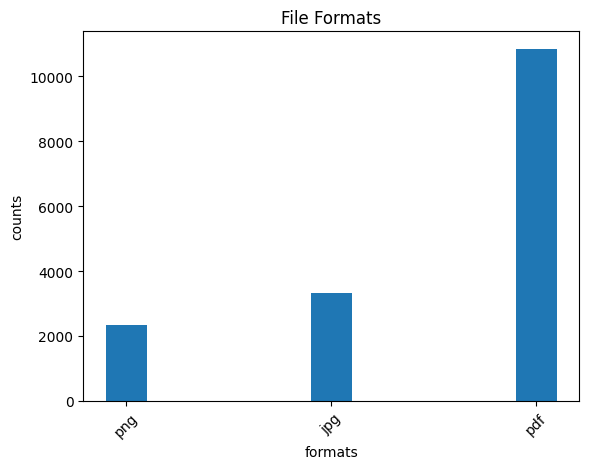

In [ ]:
counts = Counter(X['file_format'])

plt.bar(counts.keys(), counts.values(), width=0.2, align='center')
plt.xticks(rotation=45)
plt.xlabel('formats')
plt.ylabel('counts')
plt.title('File Formats')
plt.show()

In [ ]:
type(X['ocr_lines'][0])

str

In [ ]:
import ast

X['ocr_lines'] = X['ocr_lines'].apply(ast.literal_eval) #removing " "
print(len(X['ocr_lines'][0]))

26


/tmp/ipython-input-523816037.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['ocr_lines'] = X['ocr_lines'].apply(ast.literal_eval) #removing " "


In [ ]:
type(X['ocr_lines'][0])

list

In [ ]:
X['line_count'] = X['ocr_lines'].map(lambda x: len(x))
X.head()

,ocr_lines,text,file_format,line_count
0,"[Apollo Hospital, Prescription, Patient Name: ...",Apollo Hospital Prescription Patient Name: Roh...,png,26
1,"[Fortis Healthcare, Prescription, Patient Name...",Fortis Healthcare Prescription Patient Name: A...,jpg,19
2,"[Max Healthcare, Prescription, Patient Name: N...",Max Healthcare Prescription Patient Name: Neha...,pdf,26
3,"[Manipal Hospital, Prescription, Patient Name:...",Manipal Hospital Prescription Patient Name: Ne...,png,27
4,"[Fortis Healthcare, Prescription, Patient Name...",Fortis Healthcare Prescription Patient Name: S...,png,19


In [ ]:
# plt.figure()
# plt.hist(X['line_count'], bins=30)
# plt.title("Distribution of Document Lengths (OCR Lines)")
# plt.xlabel("Number of OCR Lines")
# plt.ylabel("Number of Documents")
# plt.show()

Counter({Interval(7.72, 101.333, closed='right'): 12641, Interval(101.333, 194.667, closed='right'): 2859, Interval(194.667, 288.0, closed='right'): 1000})


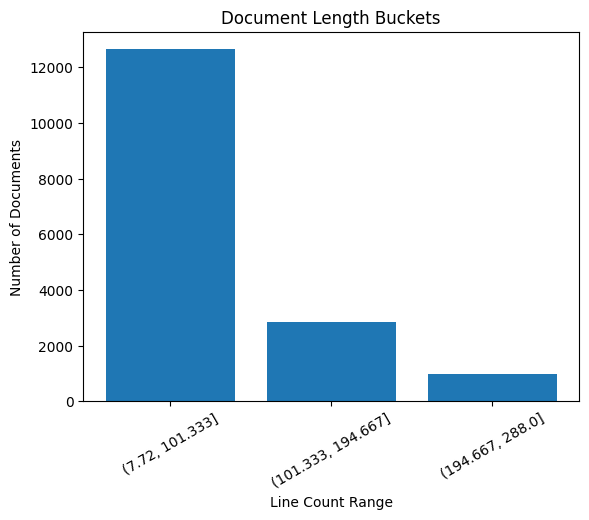

In [ ]:
buckets = pd.cut(X['line_count'], bins=3)
bucket_counts = Counter(buckets)

print(bucket_counts)

labels = [str(interval) for interval in bucket_counts.keys()]
values = list(bucket_counts.values())

plt.figure()
plt.bar(labels, values)
plt.title("Document Length Buckets")
plt.xlabel("Line Count Range")
plt.ylabel("Number of Documents")
plt.xticks(rotation=30)
plt.show()

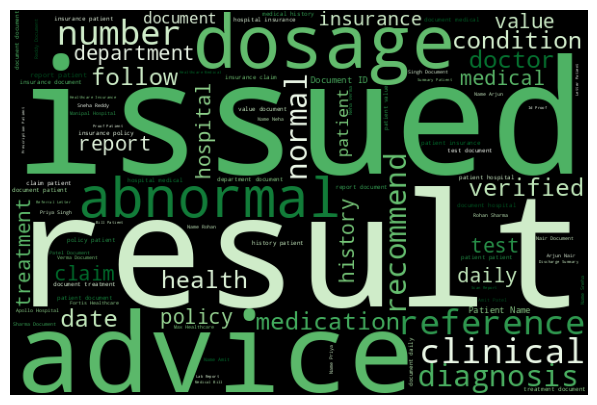

In [ ]:
from wordcloud import WordCloud

text = " ".join(X['text'])

wc = WordCloud(height=400, width=600, random_state=42, background_color='black', colormap='Greens').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis('off')
plt.show()


In [ ]:
X['word_count'] = X['text'].map(lambda x: len(x))
X.head()

,ocr_lines,text,file_format,line_count,word_count
0,"[Apollo Hospital, Prescription, Patient Name: ...",Apollo Hospital Prescription Patient Name: Roh...,png,26,1361
1,"[Fortis Healthcare, Prescription, Patient Name...",Fortis Healthcare Prescription Patient Name: A...,jpg,19,850
2,"[Max Healthcare, Prescription, Patient Name: N...",Max Healthcare Prescription Patient Name: Neha...,pdf,26,1417
3,"[Manipal Hospital, Prescription, Patient Name:...",Manipal Hospital Prescription Patient Name: Ne...,png,27,1465
4,"[Fortis Healthcare, Prescription, Patient Name...",Fortis Healthcare Prescription Patient Name: S...,png,19,910


Counter({Interval(274.088, 5594.0, closed='right'): 12551, Interval(5594.0, 10898.0, closed='right'): 2871, Interval(10898.0, 16202.0, closed='right'): 1078})


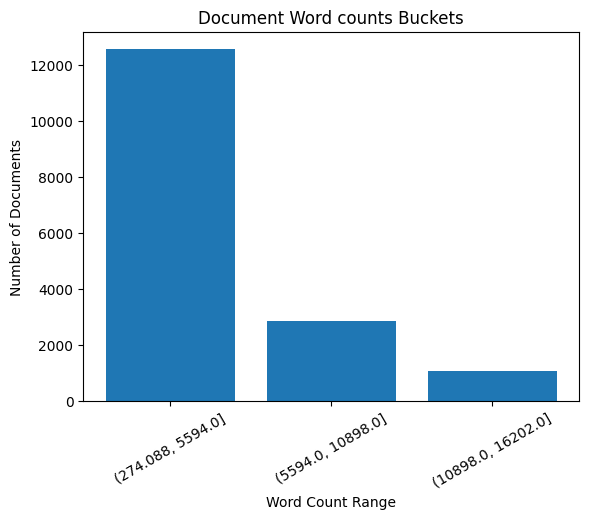

In [ ]:
buckets = pd.cut(X['word_count'], bins=3)
bucket_counts = Counter(buckets)

print(bucket_counts)

labels = [str(key) for key in bucket_counts.keys()] #For every key in bucket_counts, convert it to string and store in a list.
values = list(bucket_counts.values())

plt.figure()
plt.bar(labels, values)
plt.title("Document Word counts Buckets")
plt.xlabel("Word Count Range")
plt.ylabel("Number of Documents")
plt.xticks(rotation=30)
plt.show()

In [ ]:
X[['line_count','word_count']].corr()

,line_count,word_count
line_count,1.000000,0.999465
word_count,0.999465,1.000000


In [ ]:
#Encoding the labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_label = le.fit_transform(y)

In [ ]:
y_label

array([8, 8, 8, ..., 7, 7, 7])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y_label,stratify=y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

#common transformer for all models
preprocessor = ColumnTransformer(
    transformers=[
                ('text',TfidfVectorizer(
                     max_features=10000,
                     ngram_range=(1,2),  #bigrams
                     min_df=2,  #removes rare words
                     max_df=0.95  #removes overly common words
                 ),'text'),
                ('counts',StandardScaler(),['line_count','word_count']),
                ('file_format',OneHotEncoder(handle_unknown='ignore'),['file_format'])
    ],
    remainder='drop',
)

#transformer for naive-bayes
nb_preprocessor = ColumnTransformer(
    transformers=[
        ('text',
         TfidfVectorizer(
             max_features=5000,
             ngram_range=(1,2),
             min_df=2,
             max_df=0.95
         ),'text')
    ],
    remainder='drop',
)

In [ ]:
#SVM
from sklearn.svm import LinearSVC
svm = LinearSVC(C=1.0,class_weight='balanced')

#LogReg
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=2000,class_weight='balanced',n_jobs=-1)

#XGB
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    n_jobs=-1
)

#Naive-Bayes
from sklearn.naive_bayes import ComplementNB
nb = ComplementNB()

In [ ]:
from sklearn.pipeline import Pipeline

#svm pipeline
svm_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', svm)
])

#logreg pipeline
logreg_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', logreg)
])

#xgboost piepline
xgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', xgb)
])

#naive-bayes pipeline
nb_pipeline = Pipeline([
    ('prep', nb_preprocessor),
    ('model', nb)
])

In [ ]:
svm_pipeline.fit(X_train,y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=10000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'text'),
                                                 ('counts', StandardScaler(),
                                                  ['line_count', 'word_count']),
                                                 ('file_format',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['file_format'])])),
                ('model', LinearSVC(class_weight='balanced'))])

In [ ]:
logreg_pipeline.fit(X_train,y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=10000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'text'),
                                                 ('counts', StandardScaler(),
                                                  ['line_count', 'word_count']),
                                                 ('file_format',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['file_format'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    n_jobs=-1))])

In [ ]:
nb_pipeline.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=5000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'text')])),
                ('model', ComplementNB())])

In [ ]:
xgb_pipeline.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=10000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'text'),
                                                 ('counts', StandardScaler(),
                                                  ['line_count', 'word_count']),
                                                 ('file_format',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['file_format'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsam...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [ ]:
y_pred_svm = svm_pipeline.predict(X_test)
y_pred_logreg = logreg_pipeline.predict(X_test)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_pred_nb = nb_pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print(f"Validation_accuracy_svm:{accuracy_score(y_test,y_pred_svm)}")
print(f"Validation_accuracy_logreg:{accuracy_score(y_test,y_pred_logreg)}")
print(f"Validation_accuracy_xgb:{accuracy_score(y_test,y_pred_xgb)}")
print(f"Validation_accuracy_nb:{accuracy_score(y_test,y_pred_nb)}")


Validation_accuracy_svm:0.9824242424242424
Validation_accuracy_logreg:0.9581818181818181
Validation_accuracy_xgb:0.9981818181818182
Validation_accuracy_nb:0.9142424242424242


In [ ]:
from sklearn.metrics import confusion_matrix

print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

# print("\nLogistic Regression Confusion Matrix:")
# print(confusion_matrix(y_test, y_pred_logreg))

# print("\nXGBoost Confusion Matrix:")
# print(confusion_matrix(y_test, y_pred_xgb))

# print("\nNaive Bayes Confusion Matrix:")
# print(confusion_matrix(y_test, y_pred_nb))


SVM Confusion Matrix:
[[298   0   0   2   0   0   0   0   0   0   0]
 [  0 300   0   0   0   0   0   0   0   0   0]
 [  0   0 284   1   0   0  15   0   0   0   0]
 [  0   0   9 281   0   0  10   0   0   0   0]
 [  0   0   0   0 300   0   0   0   0   0   0]
 [  0   0   0   0   0 300   0   0   0   0   0]
 [  0   0  13   8   0   0 279   0   0   0   0]
 [  0   0   0   0   0   0   0 300   0   0   0]
 [  0   0   0   0   0   0   0   0 300   0   0]
 [  0   0   0   0   0   0   0   0   0 300   0]
 [  0   0   0   0   0   0   0   0   0   0 300]]


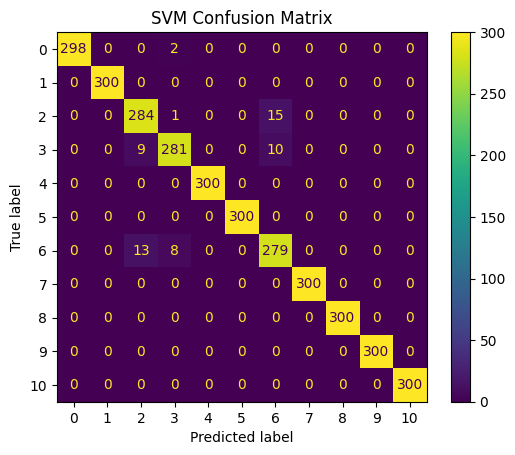

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# SVM
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.title("SVM Confusion Matrix")
plt.show()

# # Logistic Regression
# ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg)
# plt.title("Logistic Regression Confusion Matrix")
# plt.show()

# # XGBoost
# ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
# plt.title("XGBoost Confusion Matrix")
# plt.show()

# # Naive Bayes
# ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb)
# plt.title("Naive Bayes Confusion Matrix")
# plt.show()


In [ ]:
from sklearn.metrics import classification_report

print("SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

# print("Logistic Regression Classification Report:\n")
# print(classification_report(y_test, y_pred_logreg))

# print("XGBoost Classification Report:\n")
# print(classification_report(y_test, y_pred_xgb))

# print("Naive Bayes Classification Report:\n")
# print(classification_report(y_test, y_pred_nb))


SVM Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       300
           1       1.00      1.00      1.00       300
           2       0.93      0.95      0.94       300
           3       0.96      0.94      0.95       300
           4       1.00      1.00      1.00       300
           5       1.00      1.00      1.00       300
           6       0.92      0.93      0.92       300
           7       1.00      1.00      1.00       300
           8       1.00      1.00      1.00       300
           9       1.00      1.00      1.00       300
          10       1.00      1.00      1.00       300

    accuracy                           0.98      3300
   macro avg       0.98      0.98      0.98      3300
weighted avg       0.98      0.98      0.98      3300

